Raw data shape: (516, 13)


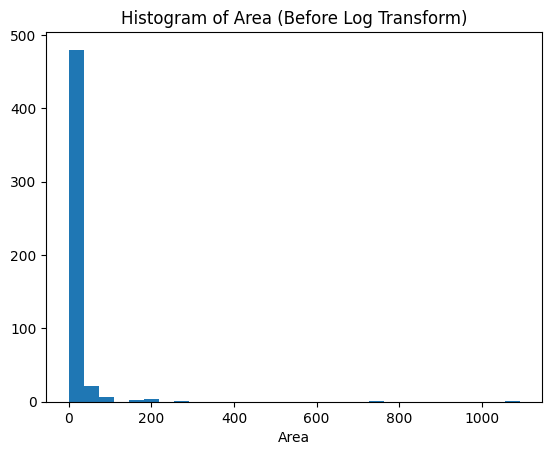

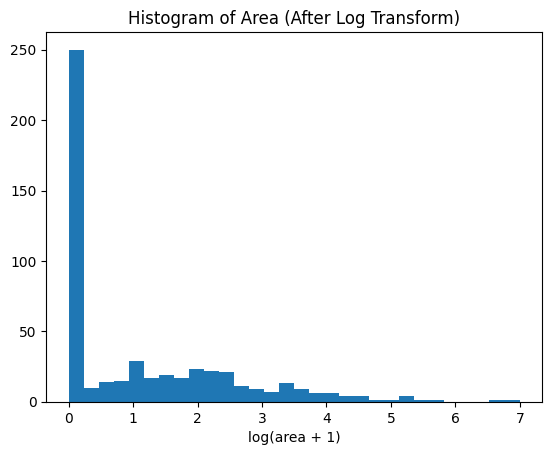


Best parameters: {'lr__fit_intercept': True}
Best CV RMSE: 1.5294451779778995

Evaluation RMSE: 1.5698459391545827
Evaluation R2: -0.058600232336769364

Regression Equation (Scaled):
y = 1.1092 + 0.1116*X - 0.0140*Y + 0.0436*FFMC + 0.2491*DMC - 0.4109*DC - 0.0999*ISI + 0.2420*temp + 0.0547*RH + 0.0654*wind + 0.0154*rain - 0.0817*month_apr - 0.0566*month_aug + 0.2441*month_dec - 0.0158*month_feb - 0.0495*month_jan - 0.0754*month_jul - 0.1125*month_jun - 0.2027*month_mar + 0.1063*month_may + 0.0544*month_oct + 0.2095*month_sep - 0.0559*day_fri - 0.0100*day_mon + 0.0480*day_sat - 0.0163*day_sun - 0.0344*day_thu + 0.0608*day_tue + 0.0119*day_wed

Regression Equation (Original Scale):
y = -0.1859 + 0.0486*X - 0.0115*Y + 0.0076*FFMC + 0.0038*DMC - 0.0016*DC - 0.0218*ISI + 0.0414*temp + 0.0034*RH + 0.0370*wind + 0.0498*rain - 0.6276*month_apr - 0.1183*month_aug + 1.8753*month_dec - 0.0797*month_feb - 0.7559*month_jan - 0.3068*month_jul - 0.6363*month_jun - 0.6596*month_mar + 2.2923*month_may

In [1]:
# ==========================================
# STEP 0: Import libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# ==========================================
# STEP 1: Load Training Data
# ==========================================
url = "https://raw.githubusercontent.com/pakornlee/ml_example/0db7e9dfd9971dc98a9404ec694ae522457075f4/forestfires.csv"

df = pd.read_csv(url)

print("Raw data shape:", df.shape)


# ==========================================
# STEP 2: Histogram Before Log Transform
# ==========================================
plt.figure()
plt.hist(df["area"], bins=30)
plt.title("Histogram of Area (Before Log Transform)")
plt.xlabel("Area")
plt.show()


# ==========================================
# STEP 3: Log Transform
# ==========================================
df["area"] = np.log1p(df["area"])


# ==========================================
# STEP 4: Histogram After Log Transform
# ==========================================
plt.figure()
plt.hist(df["area"], bins=30)
plt.title("Histogram of Area (After Log Transform)")
plt.xlabel("log(area + 1)")
plt.show()


# ==========================================
# STEP 5: One-Hot Encoding
# ==========================================
df = pd.get_dummies(df, columns=["month", "day"])

X = df.drop("area", axis=1)
y = df["area"]

features = X.columns


# ==========================================
# STEP 6: Train/Test Split
# ==========================================
X_cv, X_eval, y_cv, y_eval = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42
)


# ==========================================
# STEP 7: Cross Validation
# ==========================================
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

param_grid = {
    "lr__fit_intercept": [True, False]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=10,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_cv, y_cv)

best_model = grid.best_estimator_

print("\nBest parameters:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)


# ==========================================
# STEP 8: Final Evaluation
# ==========================================
y_pred = best_model.predict(X_eval)

rmse = np.sqrt(mean_squared_error(y_eval, y_pred))
r2 = r2_score(y_eval, y_pred)

print("\nEvaluation RMSE:", rmse)
print("Evaluation R2:", r2)


# ==========================================
# STEP 9: Extract Model
# ==========================================
scaler = best_model.named_steps["scaler"]
lr_model = best_model.named_steps["lr"]

coef = lr_model.coef_
intercept = lr_model.intercept_


# ==========================================
# STEP 10: Regression Equation (Scaled)
# ==========================================
equation_scaled = f"y = {intercept:.4f}"

for c, f in zip(coef, features):
    sign = "+" if c >= 0 else "-"
    equation_scaled += f" {sign} {abs(c):.4f}*{f}"

print("\nRegression Equation (Scaled):")
print(equation_scaled)


# ==========================================
# STEP 11: Convert Equation to Original Scale
# ==========================================
means = scaler.mean_
stds = scaler.scale_

coef_original = coef / stds
intercept_original = intercept - np.sum(coef * means / stds)

equation_original = f"y = {intercept_original:.4f}"

for c, f in zip(coef_original, features):
    sign = "+" if c >= 0 else "-"
    equation_original += f" {sign} {abs(c):.4f}*{f}"

print("\nRegression Equation (Original Scale):")
print(equation_original)


# ==========================================
# STEP 12: External Dataset
# ==========================================
url_test = "https://raw.githubusercontent.com/pakornlee/ml_example/0db7e9dfd9971dc98a9404ec694ae522457075f4/forestfires2.csv"

df_test = pd.read_csv(url_test)

df_test["area"] = np.log1p(df_test["area"])

df_test = pd.get_dummies(df_test, columns=["month", "day"])

df_test = df_test.reindex(columns=df.columns, fill_value=0)

X_test = df_test.drop("area", axis=1)

x_external = X_test.iloc[[-1]]

print("\nExternal Observation:")
print(x_external)
